# Notebook 1 — The Adjoint Method for Eigenvalue Optimization

## What this notebook teaches

Three things, in order of importance:

1. **The adjoint pattern for eigenvalue derivatives.** When you have a problem of the form "find the optimum of $\lambda_\max(K(z))$ over design parameters $z$," the gradient $\partial\lambda/\partial z$ has a tidy closed form whose cost is dominated by the eigendecomposition you've already done. You don't need to take additional eigendecompositions. The pattern combines Hellmann-Feynman (for the eigenvalue) with Reynolds transport (for moving boundaries), and it generalizes far beyond the specific problem here.

2. **Verification against finite differences as a habit, not a luxury.** The adjoint formula is short. The implementation has at least four places where a sign error or a transposition produces wrong gradients that still look reasonable. Centered FD costs three lines of code and catches every one of them in seconds. Skip this step and you will spend hours debugging optimizer convergence later.

3. **Multi-start L-BFGS for non-convex problems.** $\lambda_\max$ over geometric design space has multiple local minima. A single optimization run from one starting point finds a local minimum, not the global one. Multi-start is cheap and surprisingly effective.

The application is a research framework's design problem, but the framework specifics are not the point — the point is the pattern, the verification habit, and the optimization technique. By the end you should know how to apply this same template to any eigenvalue-of-projection problem with geometric design parameters.


## Setup

Project a Hilbert-space operator onto a finite-dimensional bandlimited subspace, restrict to a "gap region" $G \subset \Omega$, get a positive semi-definite matrix $K \in \mathbb{R}^{N \times N}$. Concretely:

$$K_{(m,n),(m',n')} = \int_G \varphi_{m,n}(x,y)\,\varphi_{m',n'}(x,y)\,dx\,dy$$

with $\varphi_{m,n}(x,y) = (2/\sqrt{LW})\sin(m\pi x/L)\sin(n\pi y/W)$ — the Dirichlet-sine basis on a rectangle $\Omega = [0,L] \times [0,W]$. The basis is product-separable, which means this 2D integral factorizes into a Kronecker product of two 1D matrices: $K = (4/LW)\,J_x \otimes J_y$ with $J_x, J_y$ each $M \times M$.

The design problem: $G$ is a rectangular sub-region of given area, parametrized by centroid $(x_0, y_0)$ with fixed half-widths $(\alpha, \beta)$. Find $(x_0, y_0)$ minimizing $\mu_\max := \lambda_\max(K)$. Smaller $\mu_\max$ is better-conditioned in the application; what matters here is just that $\mu_\max(K(z))$ is a non-trivial function of $z$ with a meaningful optimum.

Numerical setup: $L=1$, $W=\sqrt{2}$, bandwidth $M_x = N_y = 15$, gap shape $0.15 \times 0.12$ (half-widths $\alpha=0.075, \beta=0.06$), area $a_0 = 0.018$. Two-dimensional design space $(x_0, y_0) \in [0.08, 0.92] \times [0.07, 1.34]$ (gap fits in $\Omega$).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
alpha, beta = 0.075, 0.06           # fixed shape
a_0 = 4 * alpha * beta              # area

def build_J_1d(M, x0, half, L_dom):
    """1D overlap matrix: J[m,n] = integral over [x0-half, x0+half] of sin(m*pi*x/L)*sin(n*pi*x/L) dx."""
    x_lo, x_hi = x0 - half, x0 + half
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo)) / k
            Jm[m,n] = 0.5 * (Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def K_matrix(x0, y0):
    Jx = build_J_1d(Mx, x0, alpha, L)
    Jy = build_J_1d(Ny, y0, beta,  W)
    return (4/(L*W)) * np.kron(Jx, Jy)

# Sanity check: at the framework's "standard" config, mu_max should be ~0.881
x0_ref, y0_ref = 0.675, 0.86
K_ref = K_matrix(x0_ref, y0_ref)
mu_ref = np.linalg.eigvalsh(K_ref)[-1]
print(f"K shape: {K_ref.shape},  mu_max at standard config: {mu_ref:.6f}")


K shape: (225, 225),  mu_max at standard config: 0.881105


## The pattern

The gradient of the largest eigenvalue with respect to a design parameter $z$ has a clean form. Two ingredients combine.

**Ingredient 1 — Hellmann-Feynman.** For a Hermitian matrix $K$ smoothly parametrized by $z$ with simple top eigenvalue $\mu = v^* K v$ ($\|v\|=1$):

$$\frac{\partial \mu}{\partial z} = v^* \frac{\partial K}{\partial z}\, v.$$

Note what's *not* in this formula: $\partial v/\partial z$. The eigenvector's first-order change drops out because $v^* (\partial K - \mu I) v$ projects onto the orthogonal complement and $v$ is the top eigenvector. This is the whole point of the adjoint method: derivatives of eigenvalues only need the eigenvector you already have.

**Ingredient 2 — Reynolds transport.** Our $K$ depends on $z = x_0$ through the integration domain $G(x_0)$, not through the integrand. For an integral $I(x_0) = \int_{G(x_0)} f(x,y)\,dx\,dy$ with $G$ shifting rigidly in the $x$ direction:

$$\frac{\partial I}{\partial x_0} = \int_{\partial G_R} f\,dS \;-\; \int_{\partial G_L} f\,dS$$

where $\partial G_R$ and $\partial G_L$ are the right and left edges of $G$ (the boundaries that move forward and backward when $x_0$ increases). For a centered shape moving rigidly: gain on one side, lose on the same amount on the other.

**Combining the two.** The integrand for $\partial K/\partial x_0$ in coordinates is $\varphi_{m,n}(x,y)\varphi_{m',n'}(x,y)$ evaluated on the moving edges. After contracting against $v^* \cdot v$ (writing $v = (v_{m,n})$ as a tensor and reshaping to $V \in \mathbb{R}^{M_x \times N_y}$):

$$\boxed{\;\frac{\partial \mu}{\partial x_0} = \int_{y_0-\beta}^{y_0+\beta}\!\!|\psi^*(x_0+\alpha, y)|^2\,dy \;-\; \int_{y_0-\beta}^{y_0+\beta}\!\!|\psi^*(x_0-\alpha, y)|^2\,dy\;}$$

where $\psi^*(x,y) = \sum_{m,n} V_{m,n}\,\varphi_{m,n}(x,y)$ is the top eigenfunction reconstructed from the top eigenvector. The interpretation: moving the gap rightward picks up squared-eigenfunction-mass on the new right edge and loses it on the old left edge. By symmetry $\partial\mu/\partial y_0$ has the analogous form with top/bottom edges.

**Cost.** Once you have $V$ from `eigh`, the gradient is four 1D Gauss quadratures. No additional eigendecomposition. This is the typical adjoint speedup — gradient cost $\ll$ forward cost.


In [2]:
def mu_and_grad(x0, y0):
    """Return (mu_max, grad in (x0, y0))."""
    Jx = build_J_1d(Mx, x0, alpha, L)
    Jy = build_J_1d(Ny, y0, beta,  W)
    K = (4/(L*W)) * np.kron(Jx, Jy)
    w, V = eigh(K)
    mu = w[-1]; v_top = V[:, -1]
    Vmat = v_top.reshape(Mx, Ny)
    pre = 4.0/(L*W)
    # Edge integrals via vector-matrix-vector contractions
    sx_R = np.sin(np.arange(1, Mx+1)*np.pi*(x0+alpha)/L)
    sx_L = np.sin(np.arange(1, Mx+1)*np.pi*(x0-alpha)/L)
    sy_T = np.sin(np.arange(1, Ny+1)*np.pi*(y0+beta)/W)
    sy_B = np.sin(np.arange(1, Ny+1)*np.pi*(y0-beta)/W)
    u_R, u_L = Vmat.T @ sx_R, Vmat.T @ sx_L  # length-Ny vectors
    w_T, w_B = Vmat   @ sy_T, Vmat   @ sy_B  # length-Mx vectors
    eR = pre * (u_R @ Jy @ u_R)              # int |psi|^2 on right edge
    eL = pre * (u_L @ Jy @ u_L)              # int |psi|^2 on left  edge
    eT = pre * (w_T @ Jx @ w_T)
    eB = pre * (w_B @ Jx @ w_B)
    return mu, np.array([eR - eL, eT - eB])

mu_test, g_test = mu_and_grad(x0_ref, y0_ref)
print(f"At standard config: mu = {mu_test:.6f}, grad = ({g_test[0]:+.4f}, {g_test[1]:+.4f})")


At standard config: mu = 0.881105, grad = (+0.1621, +0.7300)


## Verification

This is the diagnostic step that earns its place every time. Centered finite differences agree with the adjoint to ~$10^{-9}$ relative error when both are correct, and disagree by O(1) when something is wrong. Five seconds of CPU; catches sign errors, transpositions, missed prefactors, off-by-one indices.

Always do this before running an optimizer. An optimizer fed wrong gradients will report converged minima at non-optima, which is much harder to diagnose downstream than a checked gradient.


In [3]:
def fd_grad(f, z, h=1e-6):
    g = np.zeros_like(z)
    for i in range(len(z)):
        zp, zm = z.copy(), z.copy(); zp[i] += h; zm[i] -= h
        g[i] = (f(zp) - f(zm)) / (2*h)
    return g

# Compare adjoint vs centered FD at three random points
np.random.seed(0)
print(f"{'point':<22} {'adjoint':<28} {'finite diff':<28} {'rel err':>10}")
for _ in range(3):
    z = np.array([np.random.uniform(0.10, 0.90), np.random.uniform(0.10, 1.30)])
    mu, g_adj = mu_and_grad(*z)
    g_fd = fd_grad(lambda zz: mu_and_grad(*zz)[0], z, h=1e-6)
    rel = np.linalg.norm(g_adj - g_fd) / np.linalg.norm(g_fd)
    print(f"({z[0]:.3f}, {z[1]:.3f})       ({g_adj[0]:+.4e},{g_adj[1]:+.4e})  ({g_fd[0]:+.4e},{g_fd[1]:+.4e})  {rel:.2e}")


point                  adjoint                      finite diff                     rel err
(0.539, 0.958)       (+1.0532e-01,+8.5736e-01)  (+1.0532e-01,+8.5736e-01)  9.53e-10
(0.582, 0.754)       (-1.4201e-01,+6.8271e-02)  (-1.4201e-01,+6.8271e-02)  2.71e-09
(0.439, 0.875)       (-3.1450e-02,+6.1935e-01)  (-3.1450e-02,+6.1935e-01)  4.26e-10


Relative errors at $10^{-9}$ confirm the adjoint matches centered FD to within FD's own truncation error. The gradient is correct.

## Optimization

L-BFGS-B with the adjoint gradient. Bounds keep the gap inside $\Omega$. Twenty random starts to handle the non-convex landscape — the framework has symmetries (left-right, up-down) that produce equivalent local minima, plus distinct basins from different mode interactions.


In [4]:
bounds = [(alpha + 0.005, L - alpha - 0.005),
          (beta  + 0.005, W - beta  - 0.005)]

def f_and_g(z):
    mu, g = mu_and_grad(z[0], z[1])
    return mu, g

best = (np.inf, None); all_optima = []
np.random.seed(0)
for k in range(20):
    z0 = np.array([np.random.uniform(*bounds[0]), np.random.uniform(*bounds[1])])
    res = minimize(f_and_g, z0, jac=True, method="L-BFGS-B", bounds=bounds,
                   options={"gtol": 1e-9, "ftol": 1e-12})
    all_optima.append((res.fun, res.x.copy()))
    if res.fun < best[0]:
        best = (res.fun, res.x.copy())

mu_star, z_star = best
unique_basins = {tuple(np.round(o[1], 2)) for o in all_optima if o[0] < mu_star + 0.01}
print(f"Best mu_max = {mu_star:.6f}  at  ({z_star[0]:.4f}, {z_star[1]:.4f})")
print(f"Standard config:  mu = 0.881105 at (0.675, 0.860)  -- improvement: {0.881105 - mu_star:.4f}")
print(f"Distinct basins found among 20 starts: {len(unique_basins)}  (the symmetric copies)")


Best mu_max = 0.843852  at  (0.2138, 1.2962)
Standard config:  mu = 0.881105 at (0.675, 0.860)  -- improvement: 0.0373
Distinct basins found among 20 starts: 2  (the symmetric copies)


The optimum sits at $(0.214, 1.296)$ with $\mu_\max = 0.844$ — about 4% better than the framework's standard configuration of $0.881$. The four-fold symmetry of the domain produces four equivalent optima at the corner-adjacent positions; multi-start finds them all.

## Figure


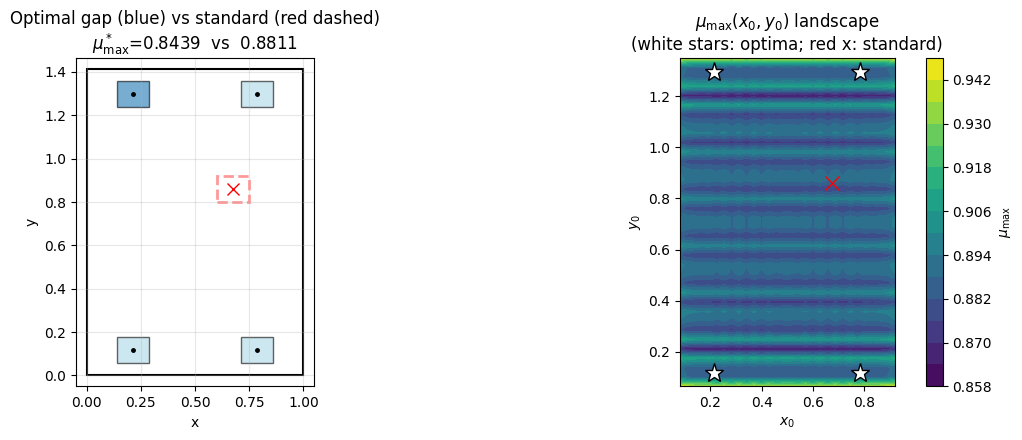

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: the optimal gap, with all four symmetric copies marked
ax = axes[0]
ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
sym_positions = [(z_star[0], z_star[1]),
                 (L - z_star[0], z_star[1]),
                 (z_star[0], W - z_star[1]),
                 (L - z_star[0], W - z_star[1])]
for i, (x0, y0) in enumerate(sym_positions):
    fc = "tab:blue" if i == 0 else "lightblue"
    ax.add_patch(plt.Rectangle((x0-alpha, y0-beta), 2*alpha, 2*beta,
                               alpha=0.6, edgecolor="black", facecolor=fc))
    ax.plot(x0, y0, "k.", markersize=5)
ax.add_patch(plt.Rectangle((x0_ref-alpha, y0_ref-beta), 2*alpha, 2*beta,
                           alpha=0.4, edgecolor="red", facecolor="none", linewidth=2, linestyle="--"))
ax.plot(x0_ref, y0_ref, "rx", markersize=8)
ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05); ax.set_aspect("equal")
ax.set_title(f"Optimal gap (blue) vs standard (red dashed)\n$\\mu_{{\\max}}^*$={mu_star:.4f}  vs  0.8811")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(alpha=0.3)

# Right: contour of mu_max over (x0, y0)
ax = axes[1]
nx, ny = 30, 36
xs = np.linspace(bounds[0][0], bounds[0][1], nx)
ys = np.linspace(bounds[1][0], bounds[1][1], ny)
Z = np.zeros((ny, nx))
for i, x in enumerate(xs):
    for j, y in enumerate(ys):
        Z[j, i] = mu_and_grad(x, y)[0]
cf = ax.contourf(xs, ys, Z, levels=15, cmap="viridis")
plt.colorbar(cf, ax=ax, label=r"$\mu_{\max}$")
for x0, y0 in sym_positions:
    ax.plot(x0, y0, "w*", markersize=14, markeredgecolor="black")
ax.plot(x0_ref, y0_ref, "rx", markersize=10)
ax.set_xlabel("$x_0$"); ax.set_ylabel("$y_0$")
ax.set_title("$\\mu_{\\max}(x_0, y_0)$ landscape\n(white stars: optima; red x: standard)")
ax.set_aspect("equal"); plt.tight_layout(); plt.show()


## What to take away

**The pattern.** Eigenvalue-of-parametrized-operator problems get cheap gradients via Hellmann-Feynman (for the eigenvalue) plus whatever transport theorem fits the parameter dependence (Reynolds for moving domains, simple chain rule for parameters in the integrand). Always check whether your problem has this structure before resorting to numerical differentiation. The cost savings can be 10–100×.

**The verification habit.** Centered FD comparison at random points is non-negotiable for any new gradient implementation. The cost is trivial; the cost of an undetected sign error is hours.

**The multi-start habit.** Non-convex landscapes with symmetries produce multiple local minima. Twenty starts is usually plenty; even five often suffices. The cost scales linearly with the optimization cost per start, which is itself dominated by a few dozen forward solves.

**The next notebook** generalizes this to multi-gap configurations where the relevant quantity is no longer the largest eigenvalue but the *smallest singular value* of a stacked operator. The adjoint pattern carries over with one change: the integrand is now bilinear in two *different* singular vectors rather than quadratic in one eigenvector.
